# K2 · A Complete System: From Data to Report

*Capstone, all teams*

This notebook assembles pieces from the whole course into one small, modular trading system: data → signal → portfolio → risk → execution → report. Each stage is a plain function with a clear contract, so each team can swap in its own module.

## 1. Motivation

Research notebooks are great for exploring one idea. A club that runs several strategies, with three teams contributing to them, needs something more: a shared structure where a signal from Signal Research, a portfolio method from Portfolio & Risk and a sentiment input from Sentiment & Alt Data can be combined, tested and compared the same way. Without it, every project rebuilds the same plumbing and makes its own timing mistakes.

## 2. Intuition

Think of an assembly line. Each station receives a well-defined input, does one job and passes on a well-defined output:

| Stage | Input → output | Owner | Course notebooks |
|---|---|---|---|
| **Data** | files → aligned prices, returns | everyone | 1, SAR4 |
| **Signal** | prices (and alt data) → a score per asset per date | Signal Research, Sentiment & Alt Data | SR1–SR7, SAR1–SAR5 |
| **Portfolio** | scores + risk estimates → target weights | Portfolio & Risk | PR1–PR4 |
| **Risk overlay** | weights + recent returns → scaled weights | Portfolio & Risk | PR5–PR7 |
| **Execution** | target weights → realised returns after delay and costs | everyone | 4, 5, 7, K1 |
| **Report** | returns → performance and risk statistics | everyone | 2, PR6 |

Two principles keep the line honest:

1. **Every stage only sees the past.** Each function receives data up to date $t$ and returns decisions for date $t$. The execution stage alone applies the delay.
2. **Every stage can be tested on its own.** In particular, we can test automatically that no stage peeks into the future.

## 3. The math

The system chains formulas from earlier notebooks. On each rebalance date $t$:

- **Signal** (SR1, time-series momentum): $s_{i,t} = P_{i,t-21}/P_{i,t-252} - 1$.
- **Portfolio** (PR3, inverse volatility among assets with a positive signal):
$$
w_{i,t} \propto \frac{\mathbb 1[s_{i,t} > 0]}{\hat\sigma_{i,t}}, \qquad \sum_i w_{i,t} = 1 \;\;(\text{or all cash if no signal is positive}).
$$
- **Risk overlay** (PR5, volatility targeting): scale the whole portfolio by $\min(\sigma^{\text{target}}/\hat\sigma_{p,t},\, L_{\max})$, where $\hat\sigma_{p,t}$ is the portfolio's estimated volatility.
- **Execution** (notebook 7 and K1): weights take effect one day later, and each unit traded costs $c$.

**The look-ahead test.** A system is free of look-ahead if, for any date $d$, the weights it produces for $d$ are *identical* whether it is given data up to $d$ or the entire dataset. We will check this automatically.

## 4. Code it

### 4.1 Configuration and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

CONFIG = {
    "universe": ["SPY", "IWM", "XLK", "XLF", "XLE", "XLV", "XLP", "XLU", "TLT", "IEF", "LQD", "HYG", "GLD", "VNQ"],
    "start": "2011-01-01",
    "vol_window": 63,          # days used to estimate volatility
    "vol_target": 0.10,        # risk overlay target, annualised
    "max_leverage": 1.5,       # cap on the overlay's scaling
    "delay_days": 1,           # execution happens this many days after the signal
    "cost_bps": 5,             # cost per unit of weight traded
}

def load_data(config):
    """Stage 1: prices and returns for the universe, plus the daily risk-free rate."""
    prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
    px = prices[config["universe"]]
    rf = (prices["^IRX"].ffill() / 100 / 252).shift(1)
    return px, px.pct_change(), rf

px, returns, rf = load_data(CONFIG)
print(f"{px.shape[1]} assets, {px.index[0].date()} to {px.index[-1].date()}")

14 assets, 2010-01-04 to 2026-09-30


### 4.2 The stages

Each function takes data **up to and including date $t$** and returns a decision for $t$. Those are the contracts the teams' modules must follow.

In [2]:
def signal_momentum(px_hist):
    """Signal stage (Signal Research). Input: prices up to t. Output: one score per asset."""
    return px_hist.iloc[-22] / px_hist.iloc[-253] - 1          # return from t-252 to t-21

def signal_sentiment(px_hist):
    """Plug-in point for Sentiment & Alt Data: return a score per asset (here: no view)."""
    return pd.Series(0.0, index=px_hist.columns)

def combine_signals(px_hist):
    """Blend the teams' signals. Momentum decides direction; sentiment could tilt it."""
    return signal_momentum(px_hist) + 0.0 * signal_sentiment(px_hist)

def portfolio_inverse_vol(scores, ret_hist, config):
    """Portfolio stage (Portfolio & Risk): inverse-vol weights among positive scores."""
    vol = ret_hist.tail(config["vol_window"]).std() * np.sqrt(252)
    raw = (scores > 0).astype(float) / vol
    return raw / raw.sum() if raw.sum() > 0 else raw * 0.0      # all cash if nothing is positive

def risk_overlay(weights, ret_hist, config):
    """Risk stage (Portfolio & Risk): scale to a volatility target, capped."""
    if weights.abs().sum() == 0:
        return weights
    window = ret_hist.tail(config["vol_window"]).fillna(0)
    port_vol = (window @ weights).std() * np.sqrt(252)            # estimated portfolio volatility
    scale = min(config["vol_target"] / port_vol, config["max_leverage"])
    return weights * scale

def decide(t_index, px, returns, config, overlay=True):
    """Run signal -> portfolio -> risk using ONLY data up to row t_index."""
    px_hist = px.iloc[: t_index + 1]
    ret_hist = returns.iloc[: t_index + 1]
    scores = combine_signals(px_hist)
    w = portfolio_inverse_vol(scores, ret_hist, config)
    return risk_overlay(w, ret_hist, config) if overlay else w

### 4.3 Execution and the backtest loop

In [3]:
def run_system(px, returns, rf, config, overlay=True, rebalance="M"):
    dates = px.index
    start = dates.searchsorted(pd.Timestamp(config["start"]))
    rebal_days = set(px.loc[config["start"]:].groupby(px.loc[config["start"]:].index.to_period(rebalance)).tail(1).index)

    targets = {}
    for k in range(start, len(dates)):
        if dates[k] in rebal_days:
            targets[dates[k]] = decide(k, px, returns, config, overlay)
    targets = pd.DataFrame(targets).T.reindex(dates[start:]).ffill().fillna(0)

    held = targets.shift(config["delay_days"]).fillna(0)                      # execution delay
    turnover = held.diff().abs().sum(axis=1).fillna(0)
    cash_weight = 1 - held.sum(axis=1)                                         # negative = borrowing
    gross = (held * returns.loc[held.index]).sum(axis=1) + cash_weight * rf.loc[held.index].fillna(0)
    net = gross - turnover * config["cost_bps"] / 1e4
    return pd.DataFrame({"gross": gross, "net": net, "turnover": turnover, "exposure": held.sum(axis=1)})

result = run_system(px, returns, rf, CONFIG)
print(f"Average gross exposure: {result['exposure'].mean():.2f}, "
      f"average daily turnover: {result['turnover'].mean():.2%}")

Average gross exposure: 1.30, average daily turnover: 1.82%


### 4.4 The look-ahead test

For 20 random rebalance dates, compute the weights twice: once giving the system the full dataset, and once cutting the data off at that date. If any stage used future data, the two would differ.

In [4]:
rng = np.random.default_rng(0)
test_dates = rng.choice(px.loc[CONFIG["start"]:].index[:-30], size=20, replace=False)
max_diff = 0.0
for d in test_dates:
    k = px.index.get_loc(d)
    w_full = decide(k, px, returns, CONFIG)                                   # full data available
    w_cut = decide(k, px.iloc[: k + 1], returns.iloc[: k + 1], CONFIG)        # data truncated at d
    max_diff = max(max_diff, (w_full - w_cut).abs().max())
print(f"Largest weight difference over 20 dates: {max_diff:.2e}")
assert max_diff < 1e-12, "Look-ahead detected!"
print("Look-ahead test passed.")

Largest weight difference over 20 dates: 0.00e+00
Look-ahead test passed.


The weights are identical to the last decimal whether or not the system can see the future. Every stage only used what it was given. This test is worth keeping in any shared codebase: if someone later adds a feature that accidentally uses a full-sample mean or an un-shifted series, it fails immediately.

### 4.5 The report: what each layer contributes

We run the system layer by layer, comparing each stage with simply holding the universe in equal weights. The one-day execution delay applies to every system layer; the last step adds trading costs.

In [5]:
def stats(r, rf):
    ex = r - rf.reindex(r.index).fillna(0)
    v = (1 + r).cumprod()
    return pd.Series({
        "CAGR": f"{v.iloc[-1] ** (252 / len(r)) - 1:.1%}",
        "Volatility": f"{r.std() * np.sqrt(252):.1%}",
        "Sharpe": f"{np.sqrt(252) * ex.mean() / ex.std():.2f}",
        "Max drawdown": f"{(v / v.cummax() - 1).min():.1%}",
    })

no_overlay = run_system(px, returns, rf, CONFIG, overlay=False)
equal_weight = returns.loc[result.index].mean(axis=1)                 # benchmark: hold everything equally

layers = pd.DataFrame({
    "Equal weight (benchmark)": equal_weight,
    "Signal + inverse-vol portfolio": no_overlay["gross"],
    "+ Vol-target overlay": result["gross"],
    "+ Trading costs (final, net)": result["net"],
}).dropna()
report = layers.apply(lambda r: stats(r, rf)).T
report

,CAGR,Volatility,Sharpe,Max drawdown
Equal weight (benchmark),9.6%,11.0%,0.74,-26.5%
Signal + inverse-vol portfolio,7.5%,9.3%,0.65,-20.4%
+ Vol-target overlay,9.1%,11.1%,0.70,-29.4%
"+ Trading costs (final, net)",8.8%,11.1%,0.68,-29.4%


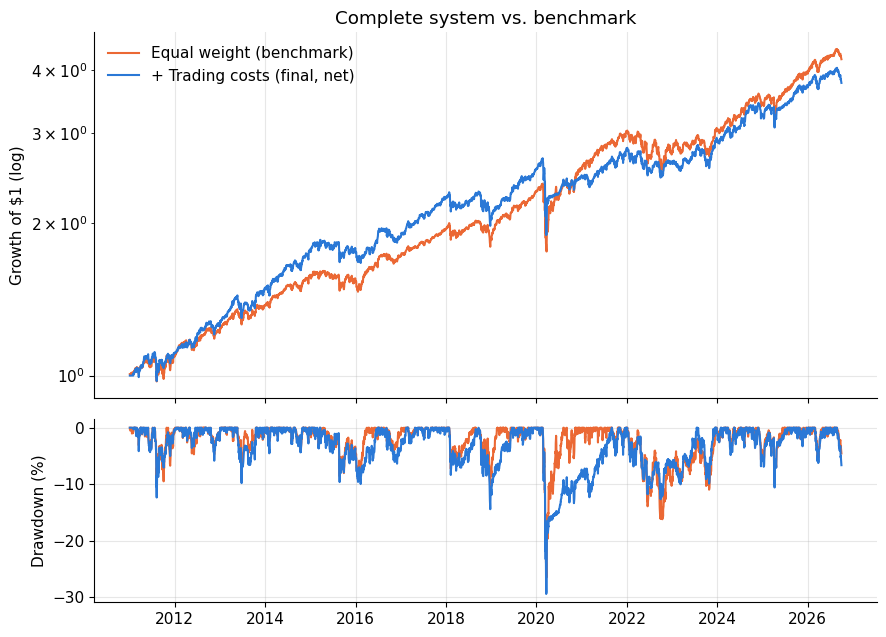

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for col, c in zip(["Equal weight (benchmark)", "+ Trading costs (final, net)"], [COLORS[1], COLORS[0]]):
    v = (1 + layers[col]).cumprod()
    axes[0].plot(v.index, v, label=col, color=c)
    axes[1].plot(v.index, (v / v.cummax() - 1) * 100, color=c)
axes[0].set_yscale("log")
axes[0].set_ylabel("Growth of $1 (log)")
axes[0].set_title("Complete system vs. benchmark")
axes[0].legend(frameon=False)
axes[1].set_ylabel("Drawdown (%)")
plt.tight_layout()
plt.show()

An honest, mixed report, which is what a real one usually looks like:

- **The signal and inverse-vol portfolio cut risk** (volatility 9.3% vs 11%, max drawdown −20% vs −27%) but earned less. Trend signals spent time out of assets that kept rising.
- **The vol-target overlay brought risk back up to the target**, using an average gross exposure of about 1.3×. It also *raised* the max drawdown to −29%. The worst loss came in the COVID crash of February–March 2020. The overlay was levered at almost 1.5× after a calm 2019, and it cuts exposure only *after* volatility has risen (PR5). In 2022, by contrast, it had already cut exposure to about 0.7×.
- **Trading costs are small** for a monthly system (about 0.3% a year).
- **Overall, the final system trails the simple benchmark slightly** on every measure.

Nothing here says the components are useless. It says that, over this period and with default settings, combining them didn't beat a diversified buy-and-hold portfolio. Finding that out *before* deploying it is exactly what the system is for.

### 4.6 Swapping a module

The point of the structure: changing one stage is one line. Here the Portfolio & Risk team tries equal weights among positive signals instead of inverse volatility.

In [7]:
def portfolio_equal(scores, ret_hist, config):
    raw = (scores > 0).astype(float)
    return raw / raw.sum() if raw.sum() > 0 else raw * 0.0

original = portfolio_inverse_vol
portfolio_inverse_vol = portfolio_equal                   # swap the module...
alt = run_system(px, returns, rf, CONFIG)
portfolio_inverse_vol = original                          # ...and put it back

pd.DataFrame({"Inverse-vol portfolio": stats(result["net"], rf),
              "Equal-weight portfolio": stats(alt["net"], rf)}).T

,CAGR,Volatility,Sharpe,Max drawdown
Inverse-vol portfolio,8.8%,11.1%,0.68,-29.4%
Equal-weight portfolio,9.9%,11.8%,0.73,-29.6%


Swapping in equal weights among the positive-signal assets took one line and improved the result slightly (Sharpe 0.73 vs 0.68). Here, inverse-vol weighting tilted the portfolio towards bonds, which did poorly after 2021. One period's ranking doesn't prove one method is better. But the experiment shows how the structure lets a team test an idea in minutes, with everything else held fixed and the same honest timing.

## 5. Takeaways and where it breaks

- **Structure beats cleverness.** Clear stage contracts let three teams work in parallel and combine their work safely.
- **Test for look-ahead automatically.** The truncation test is cheap and catches the most damaging class of bug.
- **Report by layer.** Knowing what each stage adds (or costs) tells the club where to focus effort next.
- **Where it breaks:** this system is deliberately small. A real one adds data validation, logging, configuration files, unit tests per stage, a paper-trading connection (K1) and monitoring. The universe here is also a hand-picked list of ETFs that exist today (notebook 6).
- **The results are not the point.** The parameters (12-month signal, 63-day volatility, 10% target) were chosen as textbook defaults, not optimised. That's the right habit: tune them, if at all, with walk-forward validation (SR6).

**What you could build:** turn this notebook into the club's shared Python package, with one module per stage, a test suite including the look-ahead test, and a standard report that every team's strategy produces before it is presented.